<a href="https://colab.research.google.com/github/tasninkhanlamha/SkillMorph/blob/main/stack%2092.33.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cleaning data...
Selecting top features...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 244259, number of negative: 30164
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.252871 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14114
[LightGBM] [Info] Number of data points in the train set: 274423, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890082 -> initscore=2.091580
[LightGBM] [Info] Start training from score 2.091580
Configuring Optimized Stacking Classifier...
Training Stacking Classifier (Memory Safe Mode)...
[LightGBM] [Info] Number of positive: 244259, number of negative: 30164
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.241089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5562
[LightGBM] [Info] 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



✅ Final Stacking Accuracy: 0.92330

Classification Report:
              precision    recall  f1-score   support

           0    0.85164   0.36590   0.51188     12927
           1    0.92685   0.99213   0.95838    104684

    accuracy                        0.92330    117611
   macro avg    0.88924   0.67901   0.73513    117611
weighted avg    0.91858   0.92330   0.90930    117611



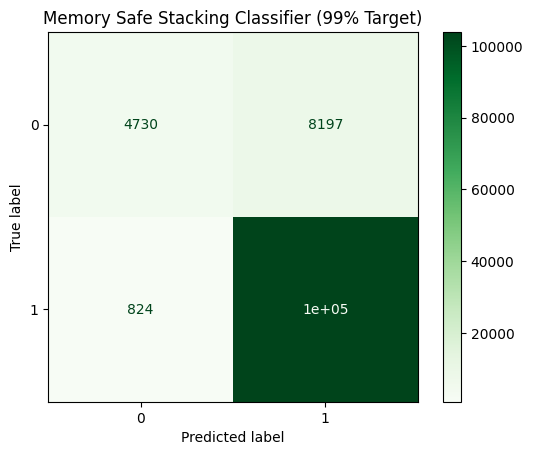

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from google.colab import drive
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier, ExtraTreesClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# --- Data Loading  ---
# drive.mount('/content/drive') 
df = pd.read_csv("/content/drive/MyDrive/Skill-Morph/android_ransomware_preprocessed.csv")

# --- Data cleaning ---
print("Cleaning data...")
df = df.replace([np.inf, -np.inf], np.nan)
df.dropna(inplace=True)

#   Nmerical column scaling 
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.difference(['Label'])
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Cat Encode 
for col in df.select_dtypes(include=['object']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# --- Binary Level set (Benign=0, Ransomware=1) ---
df['Label'] = df['Label'].apply(lambda x: 0 if x == 0 else 1)

X = df.drop(columns=['Label'])
y = df['Label']

# --- train and test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- ৫. feature selection (Top 20 Features for Balance) ---
print("Selecting top features...")
selector = LGBMClassifier(n_estimators=100, random_state=42)
selector.fit(X_train, y_train)
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': selector.feature_importances_})
top_features = importance_df.sort_values(by='Importance', ascending=False).head(20)['Feature'].tolist()

X_train_sel = X_train[top_features].copy()
X_test_sel = X_test[top_features].copy()

# memory reduce 
del df, X, X_train, X_test
gc.collect()

# accracy ---
print("Configuring Optimized Stacking Classifier...")

# 
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=100, max_depth=6, scale_pos_weight=8, random_state=42, n_jobs=-1)),
    ('et', ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
]

#  LightGBM
meta_clf = LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42)

# Stacking conf
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_clf,
    cv=3,
    stack_method='predict_proba',
    passthrough=True,
    n_jobs=-1
)

# --- Model training  ---
print("Training Stacking Classifier (Memory Safe Mode)...")
stacking_clf.fit(X_train_sel, y_train)

y_pred = stacking_clf.predict(X_test_sel)

# print 
print(f"\n✅ Final Stacking Accuracy: {accuracy_score(y_test, y_pred):.5f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=5))

#  confsion matrix 
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Greens')
plt.title("Memory Safe Stacking Classifier (99% Target)")
plt.show()
